# Stock Market Analysis and Portfolio Comparison Using Financial APIs

## Project Overview

This project analyzes and compares the performance of major technology stocks using financial market data collected through the Yahoo Finance API.

The project focuses on:
- Collecting stock market data using an API
- Cleaning and transforming financial data
- Calculating returns and volatility
- Visualizing stock performance
- Comparing correlations between stocks

The companies analyzed in this project are:
- Apple (AAPL)
- Microsoft (MSFT)
- Nvidia (NVDA)
- Amazon (AMZN)
- Meta (META)
- Google (GOOGL)

## How to Run the Notebook

 Install the required Python libraries:
```bash
pip install -r requirements.txt

```markdown id="olaphr"
# Introduction

Financial markets generate massive amounts of data every day. 
Technology companies in particular have become dominant players in global stock markets and attract strong investor interest.

The objective of this project is to analyze and compare the stock performance of major technology companies using historical market data collected through a financial API.

The analysis will focus on:
- Stock price evolution
- Daily returns
- Volatility
- Correlations between stocks
- Overall portfolio performance

This project also demonstrates how Python can be used for financial data collection, cleaning, analysis, and visualization.

# 1. Import Libraries

This section imports the Python libraries used for data collection, cleaning, analysis and visualization.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from IPython.display import display

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Data Collection Using Yahoo Finance API

This section collects historical stock market data for selected major technology companies using the Yahoo Finance API through the `yfinance` Python package.

The raw data is then exported as a CSV file so that the notebook can be re-run without needing to download the data again.

In [31]:
tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL"]

start_date = "2021-01-01"
end_date = "2025-12-31"

raw_data = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    group_by="ticker",
    auto_adjust=False,
    progress=False
)

print("Raw data downloaded successfully.")
display(raw_data.head())

Raw data downloaded successfully.


Ticker            MSFT                                                  \
Price             Open        High         Low       Close   Adj Close   
Date                                                                     
2021-01-04  222.529999  223.000000  214.809998  217.690002  208.406525   
2021-01-05  217.259995  218.520004  215.699997  217.899994  208.607574   
2021-01-06  212.169998  216.490005  211.940002  212.250000  203.198532   
2021-01-07  214.039993  219.339996  213.710007  218.289993  208.980972   
2021-01-08  218.679993  220.580002  217.029999  219.619995  210.254242   

Ticker                      AAPL                                      ...  \
Price         Volume        Open        High         Low       Close  ...   
Date                                                                  ...   
2021-01-04  37130100  133.520004  133.610001  126.760002  129.410004  ...   
2021-01-05  23823000  128.889999  131.740005  128.429993  131.009995  ...   
2021-01-06  35930700  127.720001  131.050003  126.379997  126.599998  ...   
2021-01-07  27694500  128.360001  131.630005  127.860001  130.919998  ...   
2021-01-08  22956200  132.429993  132.630005  130.229996  132.050003  ...   

Ticker         NVDA                                        META              \
Price           Low     Close  Adj Close     Volume        Open        High   
Date                                                                          
2021-01-04  12.9625  13.11350  13.076017  560640000  274.779999  275.000000   
2021-01-05  13.0870  13.40475  13.366436  322760000  268.290009  272.399994   
2021-01-06  12.5860  12.61450  12.578446  580424000  262.000000  267.750000   
2021-01-07  12.8865  13.34400  13.305858  461480000  265.899994  271.609985   
2021-01-08  13.0420  13.27675  13.238800  292528000  268.309998  268.950012   

Ticker                                                    
Price              Low       Close   Adj Close    Volume  
Date                                                      
2021-01-04  265.200012  268.940002  266.845978  15106100  
2021-01-05  268.209991  270.970001  268.860107   9871600  
2021-01-06  260.010010  263.309998  261.259766  24354100  
2021-01-07  264.779999  268.739990  266.647491  15789800  
2021-01-08  263.179993  267.570007  265.486633  18528300  

[5 rows x 36 columns]

In [32]:
raw_data.to_csv("data/raw_stock_data.csv")

print("Raw data exported to data/raw_stock_data.csv")

Raw data exported to data/raw_stock_data.csv


In [33]:
# This cell can be used to reload the saved raw data without calling the API again.
# raw_data = pd.read_csv("data/raw_stock_data.csv", header=[0, 1], index_col=0, parse_dates=True)
# display(raw_data.head())

# 3. Data Cleaning and Transformation

This section cleans and transforms the raw stock market data in order to prepare it for financial analysis.

The cleaning process includes:
- Checking for missing values
- Extracting adjusted closing prices
- Formatting the dataset
- Calculating daily returns
- Calculating cumulative returns

In [34]:
# Extract adjusted closing prices

adj_close = pd.DataFrame()

for ticker in tickers:
    adj_close[ticker] = raw_data[ticker]["Adj Close"]

display(adj_close.head())

,AAPL,MSFT,NVDA,AMZN,META,GOOGL
Date,,,,,,
2021-01-04,125.856705,208.406525,13.076017,159.331497,266.845978,85.599014
2021-01-05,127.412735,208.607574,13.366436,160.925507,268.860107,86.289322
2021-01-06,123.123833,203.198532,12.578446,156.919006,261.259766,85.437859
2021-01-07,127.325218,208.980972,13.305858,158.108002,266.647491,87.989761
2021-01-08,128.424240,210.254242,13.238800,159.134995,265.486633,89.154640


In [35]:
# Check for missing values

print("Missing values per column:")
print(adj_close.isnull().sum())

Missing values per column:
AAPL     0
MSFT     0
NVDA     0
AMZN     0
META     0
GOOGL    0
dtype: int64


In [36]:
# Remove missing values

adj_close = adj_close.dropna()

print("Dataset cleaned successfully.")
display(adj_close.head())

Dataset cleaned successfully.


,AAPL,MSFT,NVDA,AMZN,META,GOOGL
Date,,,,,,
2021-01-04,125.856705,208.406525,13.076017,159.331497,266.845978,85.599014
2021-01-05,127.412735,208.607574,13.366436,160.925507,268.860107,86.289322
2021-01-06,123.123833,203.198532,12.578446,156.919006,261.259766,85.437859
2021-01-07,127.325218,208.980972,13.305858,158.108002,266.647491,87.989761
2021-01-08,128.424240,210.254242,13.238800,159.134995,265.486633,89.154640


In [37]:
# Calculate daily returns

daily_returns = adj_close.pct_change()

display(daily_returns.head())

,AAPL,MSFT,NVDA,AMZN,META,GOOGL
Date,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.012364,0.000965,0.022210,0.010004,0.007548,0.008064
2021-01-06,-0.033661,-0.025929,-0.058953,-0.024897,-0.028269,-0.009868
2021-01-07,0.034123,0.028457,0.057830,0.007577,0.020622,0.029869
2021-01-08,0.008632,0.006093,-0.005040,0.006496,-0.004354,0.013239


In [38]:
# Calculate cumulative returns

cumulative_returns = (1 + daily_returns).cumprod()

display(cumulative_returns.head())

,AAPL,MSFT,NVDA,AMZN,META,GOOGL
Date,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,1.012364,1.000965,1.022210,1.010004,1.007548,1.008064
2021-01-06,0.978286,0.975010,0.961948,0.984859,0.979066,0.998117
2021-01-07,1.011668,1.002756,1.017577,0.992321,0.999256,1.027930
2021-01-08,1.020400,1.008866,1.012449,0.998767,0.994906,1.041538


In [39]:
# Export cleaned data

adj_close.to_csv("exports/cleaned_stock_data.csv")

print("Cleaned data exported successfully.")

Cleaned data exported successfully.


# 4. Statistical Analysis

This section analyzes the cleaned stock price data.

The objective is to calculate simple financial indicators:
- Average daily return
- Daily volatility
- Total return over the full period
- Correlation between stocks

These indicators help compare the risk and performance of the selected technology stocks.

In [40]:
# Calculate the average daily return for each stock

mean_returns = daily_returns.mean()

print("Average daily returns:")
display(mean_returns)

Average daily returns:


AAPL     0.000771
MSFT     0.000807
NVDA     0.002663
AMZN     0.000546
META     0.001108
GOOGL    0.001229
dtype: float64

In [41]:
# Calculate the average daily return for each stock

mean_returns = daily_returns.mean()

print("Average daily returns:")
display(mean_returns)

Average daily returns:


AAPL     0.000771
MSFT     0.000807
NVDA     0.002663
AMZN     0.000546
META     0.001108
GOOGL    0.001229
dtype: float64

In [42]:
# Calculate the daily volatility for each stock
# Volatility is measured as the standard deviation of daily returns

volatility = daily_returns.std()

print("Daily volatility:")
display(volatility)

Daily volatility:


AAPL     0.017558
MSFT     0.016203
NVDA     0.032911
AMZN     0.022122
META     0.027357
GOOGL    0.019627
dtype: float64

In [43]:
# Calculate the total return over the full period for each stock
# Formula: final price / first price - 1

first_prices = adj_close.iloc[0]
last_prices = adj_close.iloc[-1]

total_returns = (last_prices / first_prices) - 1

print("Total returns over the period:")
display(total_returns)

Total returns over the period:


AAPL      1.167741
MSFT      1.333756
NVDA     13.341511
AMZN      0.459410
META      1.493499
GOOGL     2.663935
dtype: float64

In [44]:
# Create a simple summary table with the main financial metrics

summary_stats = pd.DataFrame({
    "Average Daily Return": mean_returns,
    "Daily Volatility": volatility,
    "Total Return": total_returns
})

display(summary_stats)

,Average Daily Return,Daily Volatility,Total Return
AAPL,0.000771,0.017558,1.167741
MSFT,0.000807,0.016203,1.333756
NVDA,0.002663,0.032911,13.341511
AMZN,0.000546,0.022122,0.459410
META,0.001108,0.027357,1.493499
GOOGL,0.001229,0.019627,2.663935


In [45]:
# Export the summary table as a CSV file

summary_stats.to_csv("exports/portfolio_metrics.csv")

print("Portfolio metrics exported successfully.")

Portfolio metrics exported successfully.


# 5. Data Visualization

This section presents visual analysis of the stock data.

The visualizations include:
- Adjusted closing prices
- Cumulative returns
- Correlation matrix
- Total return comparison

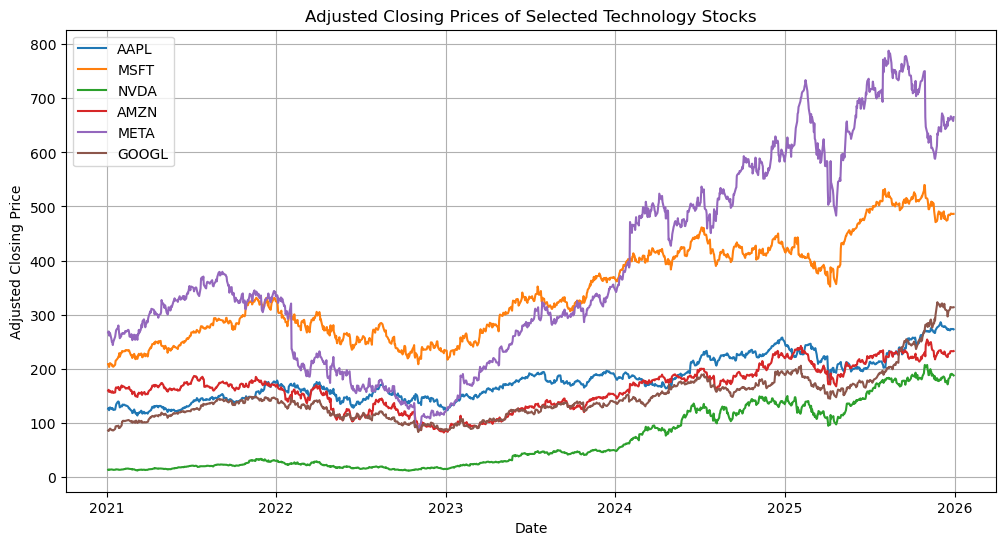

In [46]:
# Plot adjusted closing prices

plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(adj_close.index, adj_close[ticker], label=ticker)

plt.title("Adjusted Closing Prices of Selected Technology Stocks")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")
plt.legend()
plt.grid(True)
plt.show()

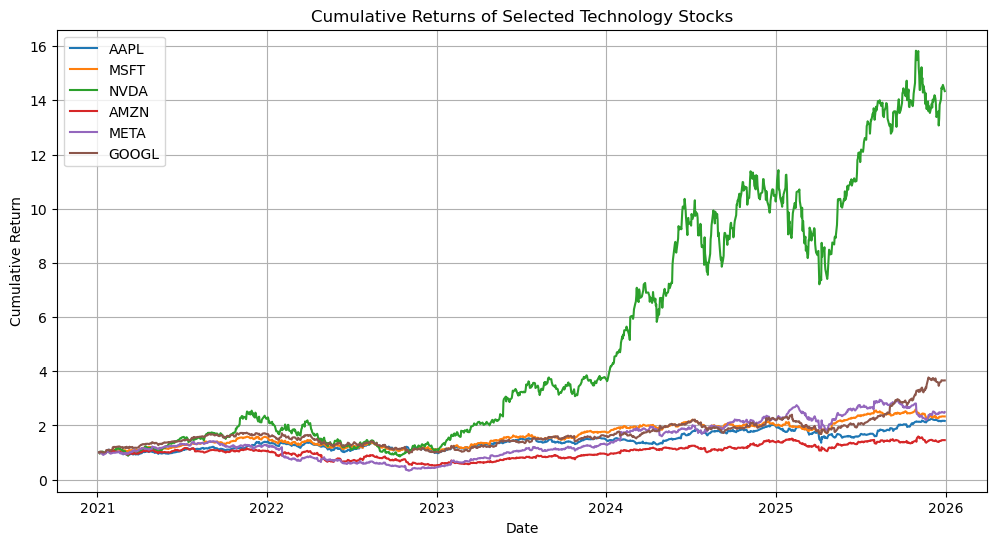

In [47]:
# Plot cumulative returns

plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

plt.title("Cumulative Returns of Selected Technology Stocks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# Calculate the correlation matrix of daily returns

correlation_matrix = daily_returns.corr()

display(correlation_matrix)

,AAPL,MSFT,NVDA,AMZN,META,GOOGL
AAPL,1.000000,0.633926,0.519824,0.561269,0.488799,0.578526
MSFT,0.633926,1.000000,0.630436,0.654683,0.591910,0.644268
NVDA,0.519824,0.630436,1.000000,0.557147,0.498231,0.527590
AMZN,0.561269,0.654683,0.557147,1.000000,0.600985,0.619263
META,0.488799,0.591910,0.498231,0.600985,1.000000,0.563580
GOOGL,0.578526,0.644268,0.527590,0.619263,0.563580,1.000000


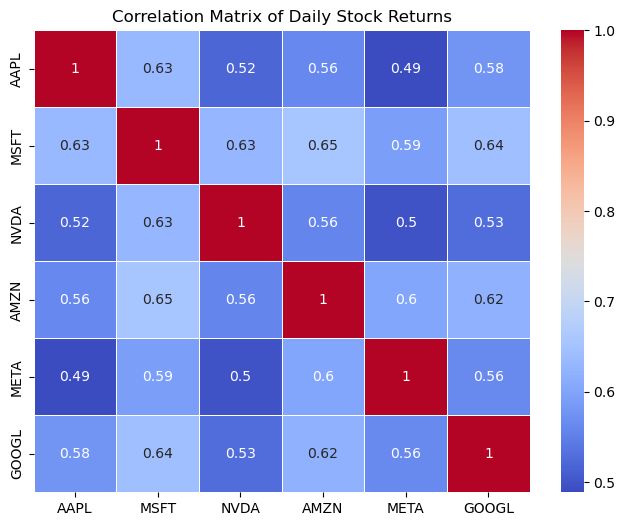

In [49]:
# Plot the correlation matrix as a heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily Stock Returns")
plt.show()

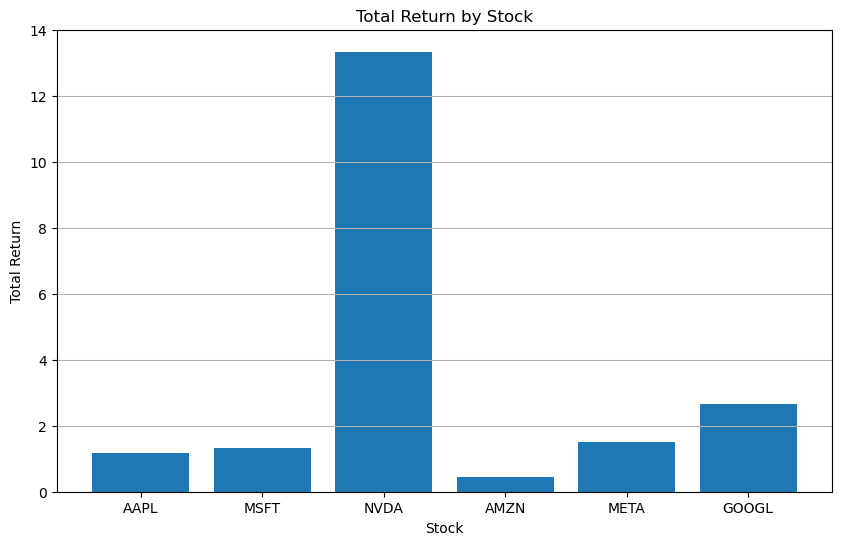

In [50]:
# Plot total returns as a bar chart

plt.figure(figsize=(10, 6))

plt.bar(total_returns.index, total_returns.values)

plt.title("Total Return by Stock")
plt.xlabel("Stock")
plt.ylabel("Total Return")
plt.grid(axis="y")
plt.show()

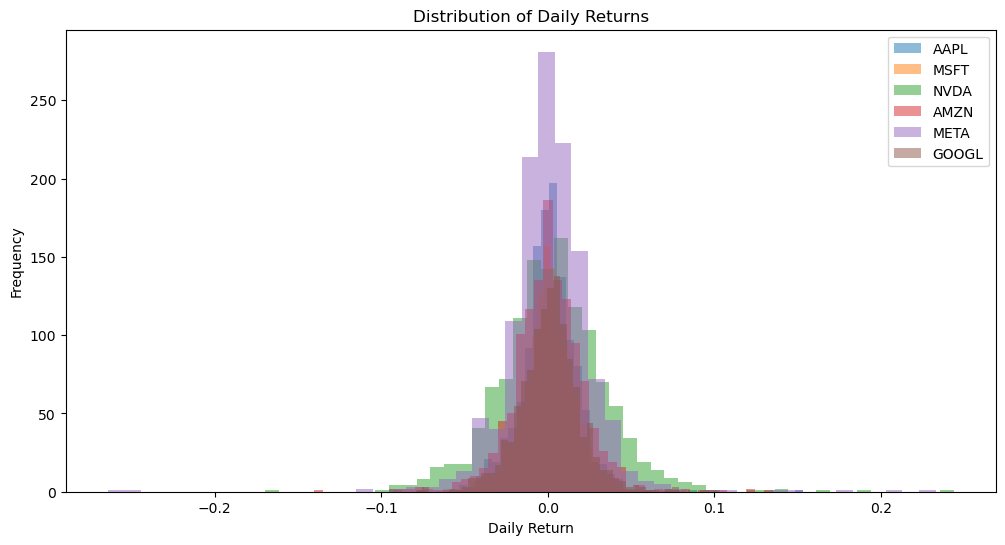

In [51]:
# Plot histograms of daily returns for each stock

plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.hist(daily_returns[ticker].dropna(), bins=50, alpha=0.5, label=ticker)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 6. Risk vs Return Analysis

This section compares the relationship between risk and return for each stock.

Risk is measured using daily volatility (standard deviation of returns), while return is measured using average daily returns.

This visualization helps evaluate which stocks offered the best balance between performance and risk.

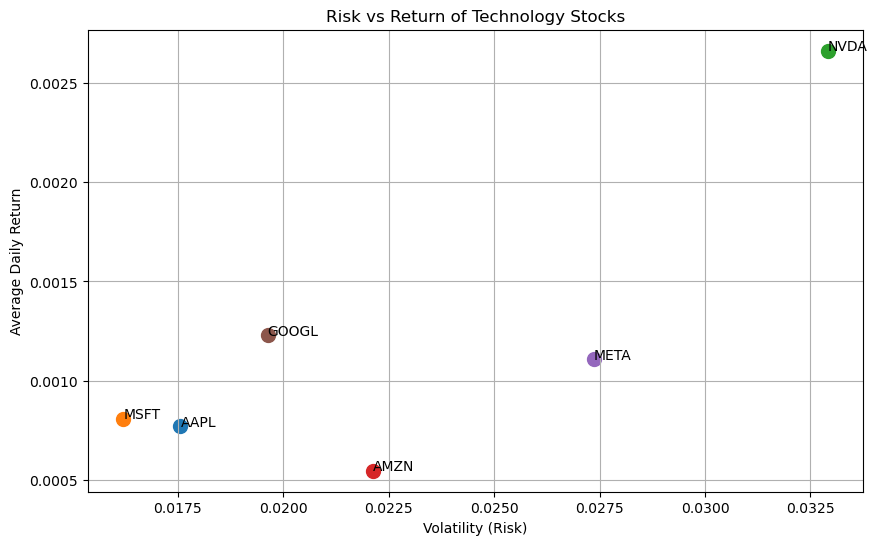

In [52]:
# Create a risk vs return scatter plot

plt.figure(figsize=(10, 6))

for ticker in tickers:
    
    # Plot the point
    plt.scatter(
        volatility[ticker],
        mean_returns[ticker],
        s=100
    )
    
    # Add ticker label next to the point
    plt.text(
        volatility[ticker],
        mean_returns[ticker],
        ticker,
        fontsize=10
    )

plt.title("Risk vs Return of Technology Stocks")

plt.xlabel("Volatility (Risk)")
plt.ylabel("Average Daily Return")

plt.grid(True)

plt.show()

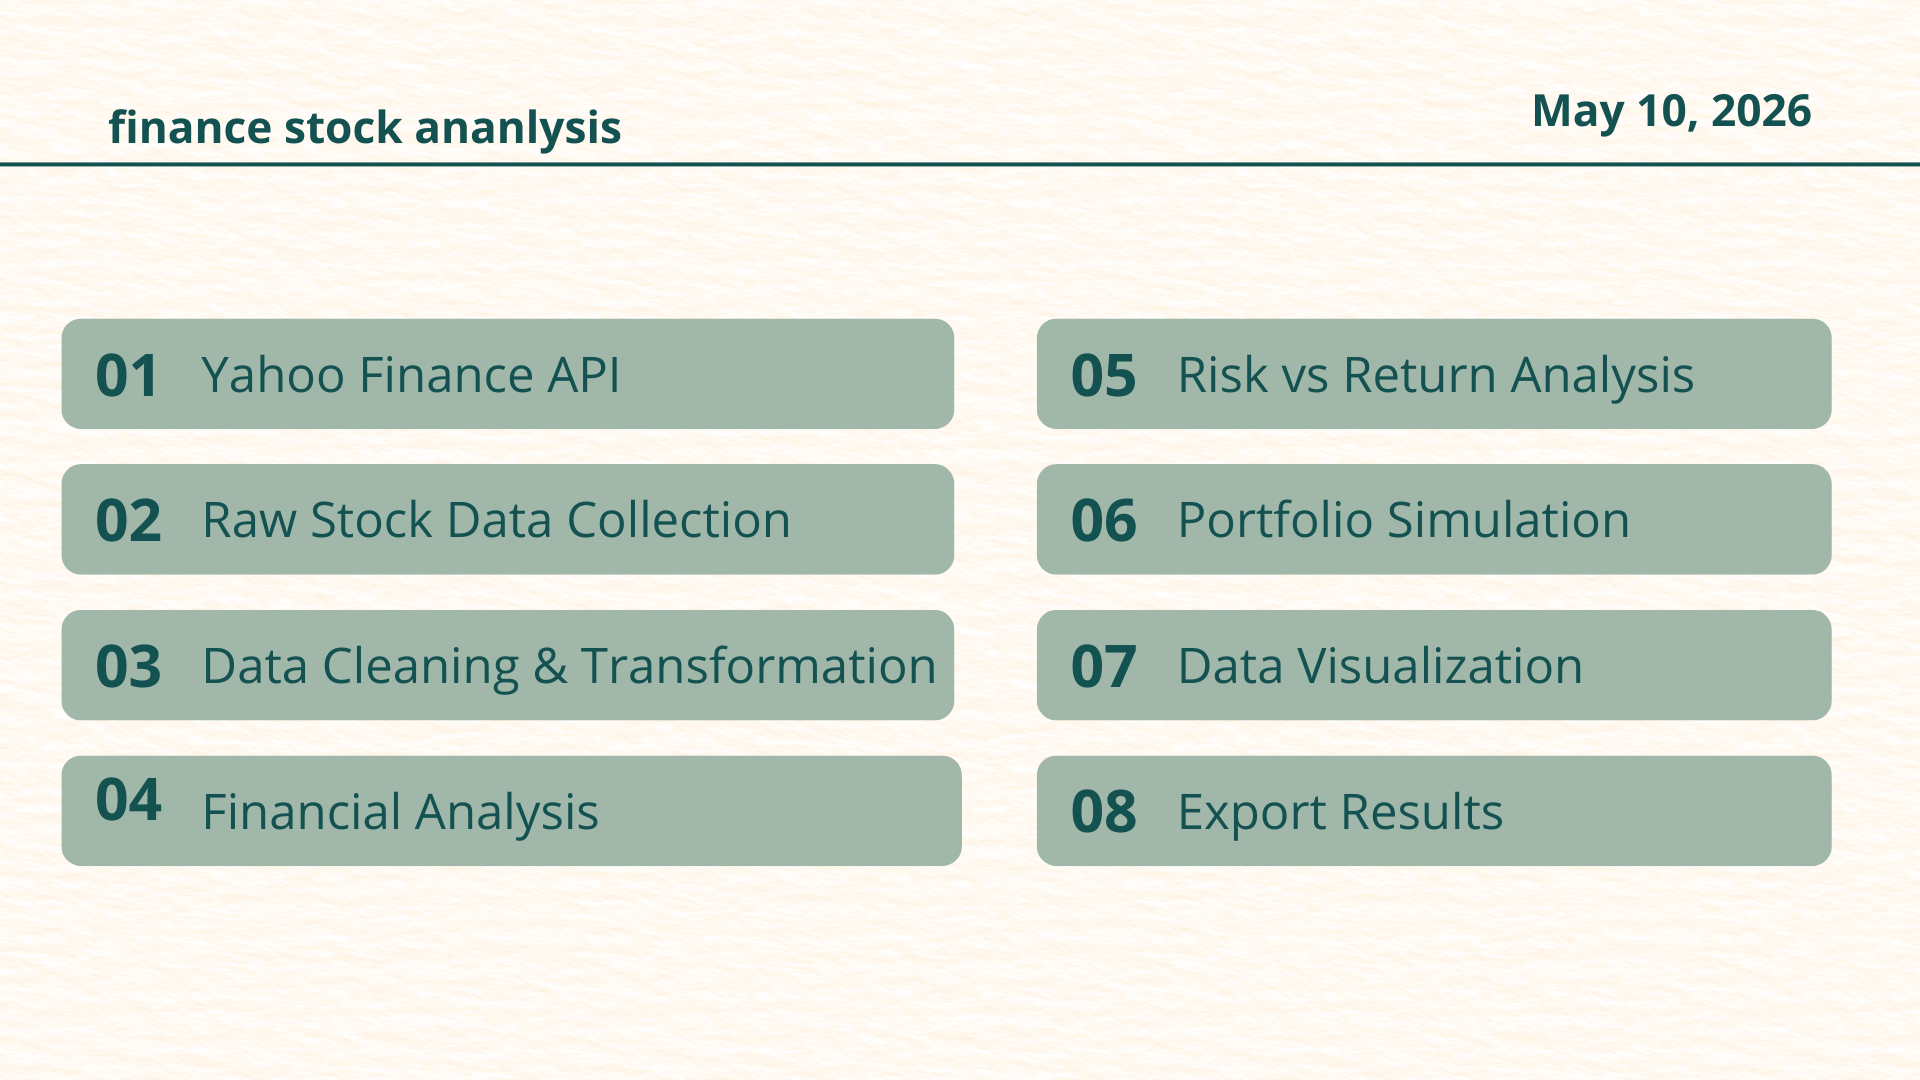

In [53]:
from IPython.display import Image

Image(filename="images/pipeline.png")

# 7. Conclusion

This project analyzed the performance of major technology stocks using historical financial market data collected through the Yahoo Finance API.

The analysis showed significant differences in both returns and volatility between the selected companies. Some stocks generated higher overall returns but also experienced higher levels of risk, while others showed more stable and consistent performance over time.

The risk versus return analysis highlighted the importance of comparing performance with volatility when evaluating investment opportunities. Combining multiple assets can help investors achieve different balances between expected return and risk.

The visualizations also revealed strong correlations between major technology companies, reflecting the influence of common market trends within the technology sector.

Overall, this project demonstrated how Python can be used for:
- Financial data collection through APIs
- Data cleaning and transformation
- Statistical analysis
- Portfolio analysis
- Financial data visualization

This project provided a practical introduction to financial data analysis and portfolio management using Python and real market data.

## Statement of AI Use

AI tools, including ChatGPT, were used to support parts of this project.  
The AI assistance was mainly used to help improve markdown explanations, clarify the structure of the notebook, debug errors, and correct some parts of the code.

The project topic, data source, analysis, visualizations, and final interpretation were reviewed and understood before submission. No AI-generated or fictional data was used; the project relies on real financial data collected through the Yahoo Finance API.